In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import optuna
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import precision_recall_curve

os.chdir('/home/onyxia/work/bdc-apicil-g1')

from src.model import FEATURES, split_data, evaluate, save_model

optuna.logging.set_verbosity(optuna.logging.WARNING)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('data/processed/panel_final.csv', low_memory=False)
print(f'{len(df):,} observations, {df.shape[1]} colonnes')

cols_indices = [col for col in df.columns if 'indice' in col]
FEATURES_INDICES = [f for f in FEATURES if f not in cols_indices]

x_train, x_test, y_train, y_test = split_data(df, features=FEATURES_INDICES)

def clean_feature_names(dataframe):
    """Remplace les caractères spéciaux dans les noms de colonnes par des underscores."""
    dataframe = dataframe.copy()
    dataframe.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col) for col in dataframe.columns
    ]
    return dataframe

x_train_lgbm = clean_feature_names(x_train)
x_test_lgbm  = clean_feature_names(x_test)

print(f'Train : {len(x_train_lgbm):,} | Test : {len(x_test_lgbm):,}')

1,383,526 observations, 133 colonnes
Train : 1,001,183 observations (2.40% de résiliations)
Test  : 382,343 observations (1.75% de résiliations)
Train : 1,001,183 | Test : 382,343


In [3]:
def clean_feature_names(df):
    """Remplace les caractères spéciaux dans les noms de colonnes par des underscores."""
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]', '_', col)
        for col in df.columns
    ]
    return df

x_train_lgbm = clean_feature_names(x_train)
x_test_lgbm  = clean_feature_names(x_test)

FEATURES_LGBM = list(x_train_lgbm.columns)
print(f'{len(FEATURES_LGBM)} features après nettoyage')
print('Exemple de noms nettoyés :', FEATURES_LGBM[:5])

95 features après nettoyage
Exemple de noms nettoyés : ['Sexe', 'Compte_personnel____ge', 'Est_salari___', 'Nb_d_ayant_droit', 'Nb_de_r_cla_depuis_mai_2023']


In [4]:
tscv = TimeSeriesSplit(n_splits=5)

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 300),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 200),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
    }

    model = LGBMClassifier(
        **params,
        is_unbalance=True,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

    scores = cross_val_score(
        model, x_train_lgbm, y_train,
        cv=tscv,
        scoring='roc_auc',
        n_jobs=-1,
    )
    return scores.mean()

In [5]:
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10),
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nMeilleure AUC en CV : {study.best_value:.4f}')
print(f'Meilleurs paramètres : {study.best_params}')

Best trial: 44. Best value: 0.753575: 100%|██████████| 50/50 [49:26<00:00, 59.33s/it] 


Meilleure AUC en CV : 0.7536
Meilleurs paramètres : {'n_estimators': 631, 'learning_rate': 0.029530630849608656, 'max_depth': 3, 'num_leaves': 66, 'subsample': 0.8819468873034886, 'colsample_bytree': 0.707127374936204, 'min_child_samples': 199, 'reg_alpha': 0.2533314253054741, 'reg_lambda': 1.2917313095355604e-08}


In [6]:
best_model = LGBMClassifier(
    **study.best_params,
    is_unbalance=True,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

best_model.fit(x_train_lgbm, y_train)
print('Entraînement terminé.')

Entraînement terminé.



Modèle : LGBMClassifier
AUC-ROC   : 0.7143  — aire sous la courbe ROC
AUC-PR    : 0.0372  — aire sous la courbe Précision-Recall (plus fiable avec classes déséquilibrées)
Recall    : 0.2520  — taux de résiliants détectés
Précision : 0.0479  — part de vrais résiliants parmi les alertes
F1        : 0.0805  — équilibre recall/précision
F2        : 0.1361  — pénalise davantage les faux négatifs
MCC       : 0.0737  — robuste au déséquilibre des classes
Brier     : 0.0842  — calibration des probabilités (plus bas = mieux)

              precision    recall  f1-score   support

           0       0.99      0.91      0.95    375637
           1       0.05      0.25      0.08      6706

    accuracy                           0.90    382343
   macro avg       0.52      0.58      0.51    382343
weighted avg       0.97      0.90      0.93    382343



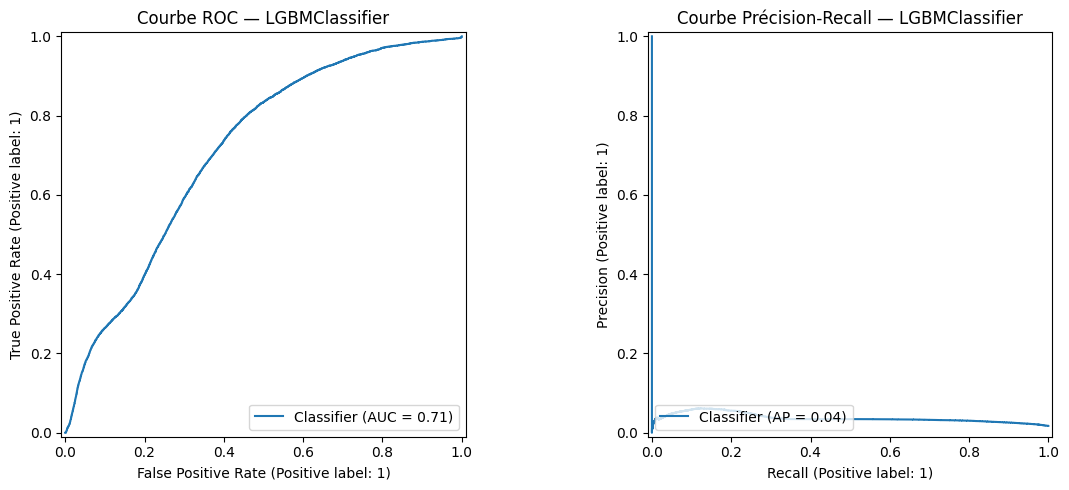

In [7]:
metrics = evaluate(best_model, x_test_lgbm, y_test)

In [8]:
save_model(best_model, 'lightgbm_optuna_chomage')

Modèle sauvegardé dans models/auc_roc/lightgbm_optuna_chomage.pkl


'models/auc_roc/lightgbm_optuna_chomage.pkl'

In [ ]:
importances = pd.Series(best_model.feature_importances_, index=x_train_lgbm.columns)
importances.sort_values(ascending=False).head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 variables — LightGBM Optuna')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('reports/figures/lgbm_optuna_chomage_importances.png', dpi=150)
plt.show()